<a href="https://colab.research.google.com/github/jfar/cryptobot/blob/main/talib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
def candlesticks(df, w=1, format='%d-%m-%Y'):
  prices = copy(df.dropna())
  prices.reset_index(inplace=True)
  if 'Date' in prices:
    prices['Date'] = prices['Date'].apply(mpl_dates.date2num)
  else:
    prices['Datetime'] = prices['Datetime'].apply(mpl_dates.date2num)

  fig, ax = plt.subplots(figsize=[10,7])
  candlestick_ohlc(ax, prices.values, width=w, colorup='green',colordown='red',alpha=0.8)
  date_format = mpl_dates.DateFormatter(format)
  ax.xaxis.set_major_formatter(date_format)
  fig.autofmt_xdate()

### Install talib

In [ ]:
url = 'https://anaconda.org/conda-forge/libta-lib/0.4.0/download/linux-64/libta-lib-0.4.0-h166bdaf_1.tar.bz2'
!curl -L $url | tar xj -C /usr/lib/x86_64-linux-gnu/ lib --strip-components=1
url = 'https://anaconda.org/conda-forge/ta-lib/0.4.19/download/linux-64/ta-lib-0.4.19-py39hd257fcd_4.tar.bz2'
!curl -L $url | tar xj -C /usr/local/lib/python3.9/dist-packages/ lib/python3.9/site-packages/talib --strip-components=3

In [ ]:
!pip install yfinance
!pip install mpl_finance

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from mpl_finance import candlestick_ohlc
import matplotlib.dates as mpl_dates
from copy import copy
import talib
from sklearn.linear_model import LinearRegression, LogisticRegression

plt.style.use('ggplot')

In [ ]:
df = yf.download('SPY',period='200D', interval='1D')

[*********************100%***********************]  1 of 1 completed


In [ ]:
df['sma5'] = talib.SMA(df.Close, 5)
df['sma20'] = talib.SMA(df.Close, 20)

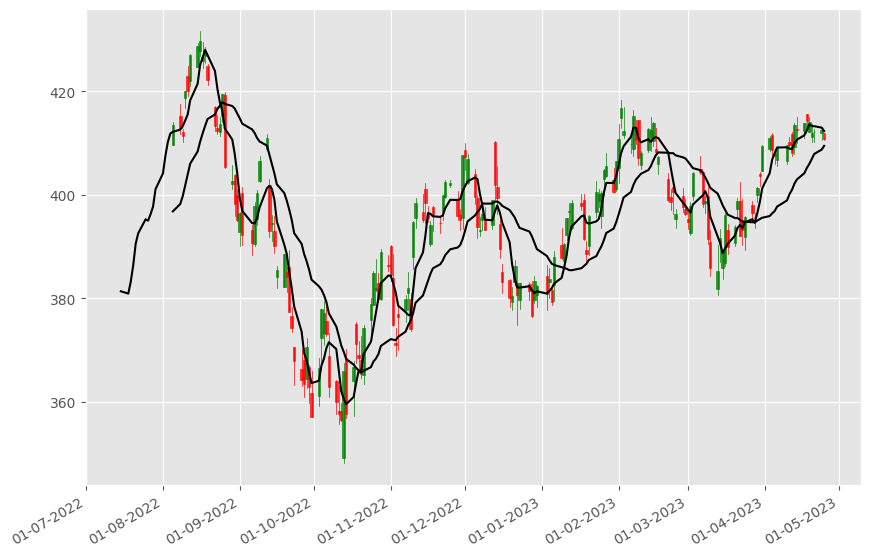

In [ ]:
candlesticks(df)
plt.plot(df['sma5'],'k')
plt.plot(df['sma20'],'k')

In [ ]:
spy = yf.download('SPY')

[*********************100%***********************]  1 of 1 completed


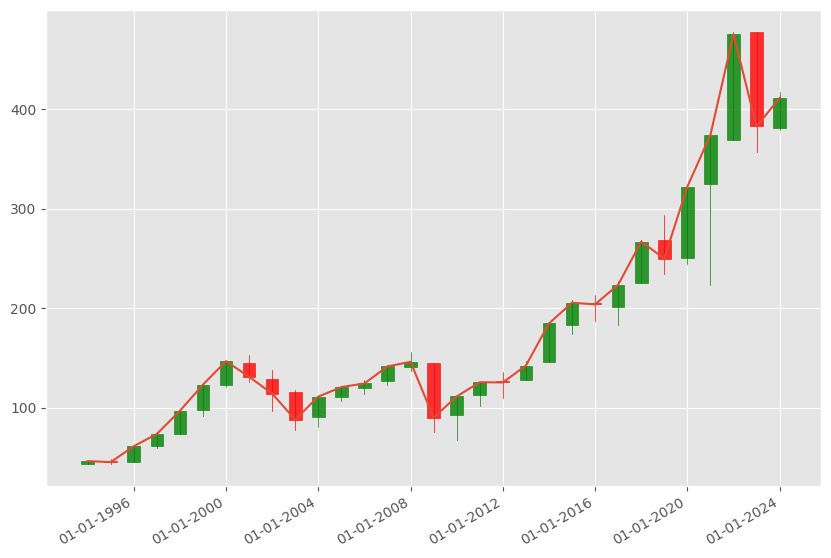

In [ ]:
annual = spy.Close.resample('1Y').ohlc()
candlesticks(annual, w=200)
plt.plot(annual.close)

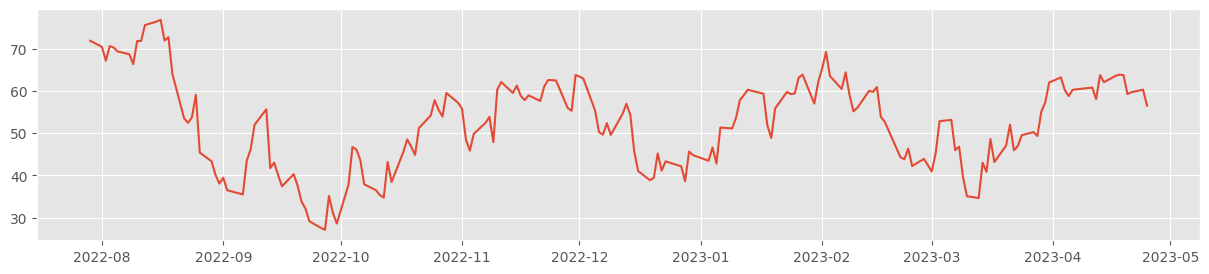

In [ ]:
plt.figure(figsize=[15,3])
df['rsi'] = talib.RSI(df.Close,14)
plt.plot(df['rsi'])

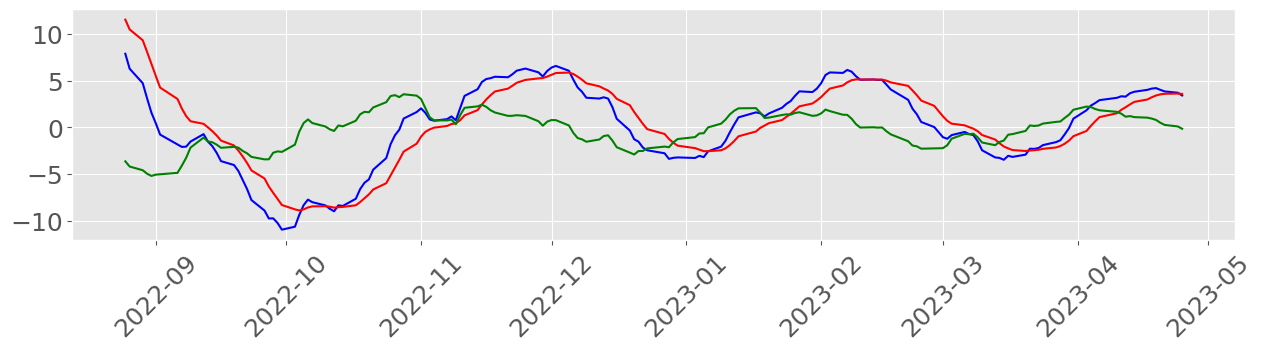

In [ ]:
macd,sig,hist = talib.MACD(df.Close,12,26,9)
plt.figure(figsize=[15,3])
plt.xticks(rotation=45,fontsize=18)
plt.yticks(fontsize=18)
plt.plot(macd,'b-',sig,'r-',hist,'g-')

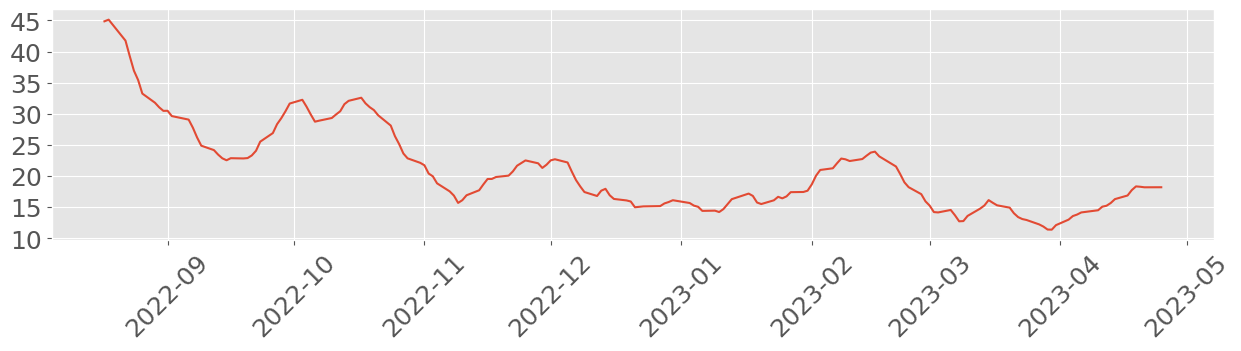

In [63]:
adx = talib.ADX(df.High,df.Low,df.Close,14)
plt.figure(figsize=[15,3])
plt.xticks(rotation=45,fontsize=18)
plt.yticks(fontsize=18)
plt.plot(adx)

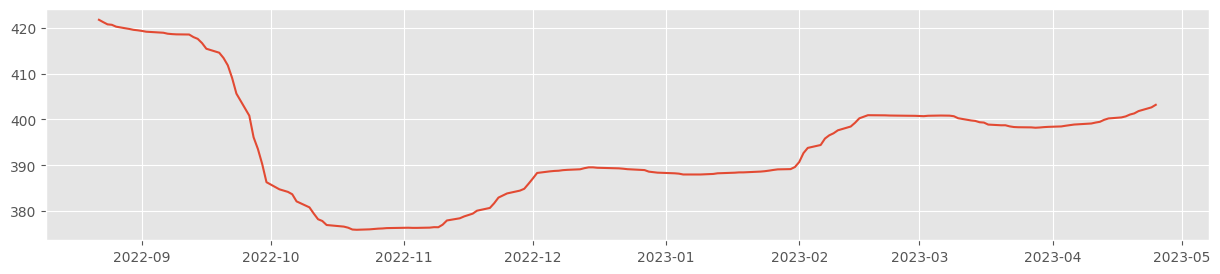

In [70]:
kama = talib.KAMA(df.Close)
plt.figure(figsize=[15,3])
plt.plot(kama)

In [88]:
results = []
cols = []
for attr in dir(talib):
  if attr[:3] == 'CDL':
    res = getattr(talib,attr)(df.Open,df.High,df.Low,df.Close)
    results.append(res)
    cols.append(attr)
patterns = pd.DataFrame(results).T
patterns.columns = cols